In [55]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision

from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
import torchvision.transforms as transforms


In [56]:
# Spliting training and testing data

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageFolder(
    root ="data/PetImages",
    transform = transform
)





In [57]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

trainset, testset = random_split(dataset, [train_size , test_size])

In [58]:
from torch.utils.data import DataLoader

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size = 32, shuffle = False)

# Build CNN Model

In [59]:
class CNN(nn.Module):
    
    def __init__(self):

        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

        )

        self.fc_layers = nn.Sequential(

            nn.Linear(28*28*128,256),
            nn.ReLU(),

            nn.Linear(256, 2)

        )

    def forward(self , x):

            x = self.conv_layers(x)

            x = x.view(x.size(0), -1)

            x = self.fc_layers(x)

            return x 

           
        

In [60]:
model = CNN()

In [61]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training the CNN

In [62]:
train_losses = []

val_losses = []

best_val_loss = float("inf")

epochs = 10

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for xb, yb in trainloader:

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss/len(trainloader)

    train_losses.append(epoch_train_loss)

    # Validation

    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for xb, yb in testloader:

            outputs = model(xb)

            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss/len(testloader)

    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Training Loss : {epoch_train_loss :.4f}")
    print(f"Validation Loss : {epoch_val_loss :.4f}")

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

    

Epoch 1/10
Training Loss : 0.6673
Validation Loss : 0.6314
Epoch 2/10
Training Loss : 0.5581
Validation Loss : 0.5337
Epoch 3/10
Training Loss : 0.4696
Validation Loss : 0.4936
Epoch 4/10
Training Loss : 0.3672
Validation Loss : 0.4931
Epoch 5/10
Training Loss : 0.2428
Validation Loss : 0.6180
Epoch 6/10
Training Loss : 0.1129
Validation Loss : 0.8580
Epoch 7/10
Training Loss : 0.0472
Validation Loss : 1.2174
Epoch 8/10
Training Loss : 0.0290
Validation Loss : 1.5113
Epoch 9/10
Training Loss : 0.0283
Validation Loss : 1.6118
Epoch 10/10
Training Loss : 0.0259
Validation Loss : 1.6513


# Evaluation



Accuracy: 0.752
Precision: 0.7523771790808241
Recall: 0.7553699284009546
[[1861  625]
 [ 615 1899]]


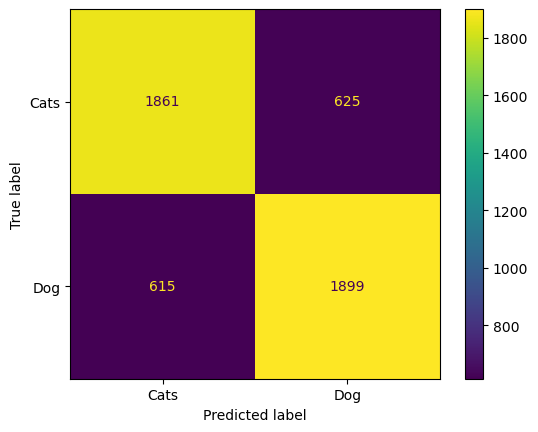

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()

y_true =[]

y_pred = []

with torch.no_grad():

    for images , labels in testloader:

        outputs = model(images)

        _,predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())

        y_pred.extend(predicted.numpy())



accuracy = accuracy_score(y_true , y_pred)

print("Accuracy:", accuracy)


precision = precision_score(y_true, y_pred)

print("Precision:", precision)


recall = recall_score( y_true, y_pred)

print("Recall:", recall)

cm = confusion_matrix(y_true , y_pred)

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cats", "Dog"]).plot()

plt.show()
    

